# Part 0 — Marginal Sentiment Distributions

For each `model_strategy` code and each `parent_motivation` code independently, characterize
the full distribution of `highlight_sentiment` (1–7).

**Outputs:** `marginal_sentiment_by_strategy.png`, `marginal_sentiment_by_motivation.png`,
`marginal_strategy_summary.csv`, `marginal_motivation_summary.csv`

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK.')

Imports OK.


In [13]:
DATA_DIR   = Path('../data-exports/20260412_183830')
OUTPUT_DIR = DATA_DIR / 'highlight_analysis_output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Sentiment scores + scenario metadata + demographics from df_sel
df_sel = pd.read_csv(OUTPUT_DIR / 'df_sel.csv')

# Motivation + strategy codes from R5_highlights_coded (source of truth)
# R5_highlights_coded is a sibling of highlight_analysis_output under 20260412_183830/
r5 = pd.read_csv(DATA_DIR / 'R5_highlights_coded', sep='\t')
r5.columns = r5.columns.str.strip()
r5 = r5.rename(columns={
    'highlight_id':      'selection_id',
    'Parent Motivation': 'parent_motivation',
    'Model Strategy':    'model_strategy',
})
r5 = r5[r5['selection_id'].notna() & (r5['selection_id'].astype(str).str.strip() != '')]

# Normalize typo: "Strong Emotion" -> "Strong Emotions"
r5['parent_motivation'] = r5['parent_motivation'].replace(
    'Response Could Evoke Strong Emotion', 'Response Could Evoke Strong Emotions'
)

# Deduplicate: some highlights appear multiple times (duplicate export rows)
r5_dedup = r5.drop_duplicates(subset='selection_id', keep='first')

# Override motivation + strategy in df_sel with R5 values
df_sel = df_sel.drop(columns=['parent_motivation', 'model_strategy'], errors='ignore')
df_sel = df_sel.merge(
    r5_dedup[['selection_id', 'parent_motivation', 'model_strategy']],
    on='selection_id', how='left'
)

print(f'df_sel: {df_sel.shape}')
print(f'  highlight_sentiment: {df_sel["highlight_sentiment"].notna().sum()} non-null')
print(f'  model_strategy:      {df_sel["model_strategy"].notna().sum()} non-null')
print(f'  parent_motivation:   {df_sel["parent_motivation"].notna().sum()} non-null')
print(f'\nMotivation value counts:')
display(df_sel['parent_motivation'].value_counts())

df_sel: (267, 48)
  highlight_sentiment: 267 non-null
  model_strategy:      245 non-null
  parent_motivation:   264 non-null

Motivation value counts:


parent_motivation
Response Usefulness                          94
Response Risk Awareness                      50
Response Could Evoke Strong Emotions         50
Child Intentions                             19
Response Identification of the Root Cause    16
Response Organization                        16
Response Complexity                          13
Response Confirmation / Contradiction         6
Name: count, dtype: int64

In [14]:
# df_strat: rows with non-null strategy + sentiment
df_strat = df_sel[
    df_sel['model_strategy'].notna() & df_sel['highlight_sentiment'].notna()
].copy()

# df_motiv: rows with non-null motivation + sentiment
df_motiv = df_sel[
    df_sel['parent_motivation'].notna() & df_sel['highlight_sentiment'].notna()
].copy()

# Pool sparse motivation codes (n < 5) into 'Other'
motiv_counts = df_motiv['parent_motivation'].value_counts()
#sparse_codes  = motiv_counts[motiv_counts < 5].index.tolist()
df_motiv['motivation_pooled'] = df_motiv['parent_motivation']#.apply(
#    lambda x: 'Other' if x in sparse_codes else x
#)

OVERALL_MEAN = df_sel['highlight_sentiment'].dropna().mean()

print(f'df_strat : {len(df_strat)} rows  ({df_strat["model_strategy"].nunique()} strategy codes)')
print(f'df_motiv : {len(df_motiv)} rows  ({df_motiv["parent_motivation"].nunique()} motivation codes)')
#if sparse_codes:
#    print(f'Pooled into Other: {sparse_codes}')
print(f'Overall mean sentiment: {OVERALL_MEAN:.3f}')

df_strat : 245 rows  (11 strategy codes)
df_motiv : 264 rows  (8 motivation codes)
Overall mean sentiment: 5.404


## Part 0b — Strategy: Marginal Distributions

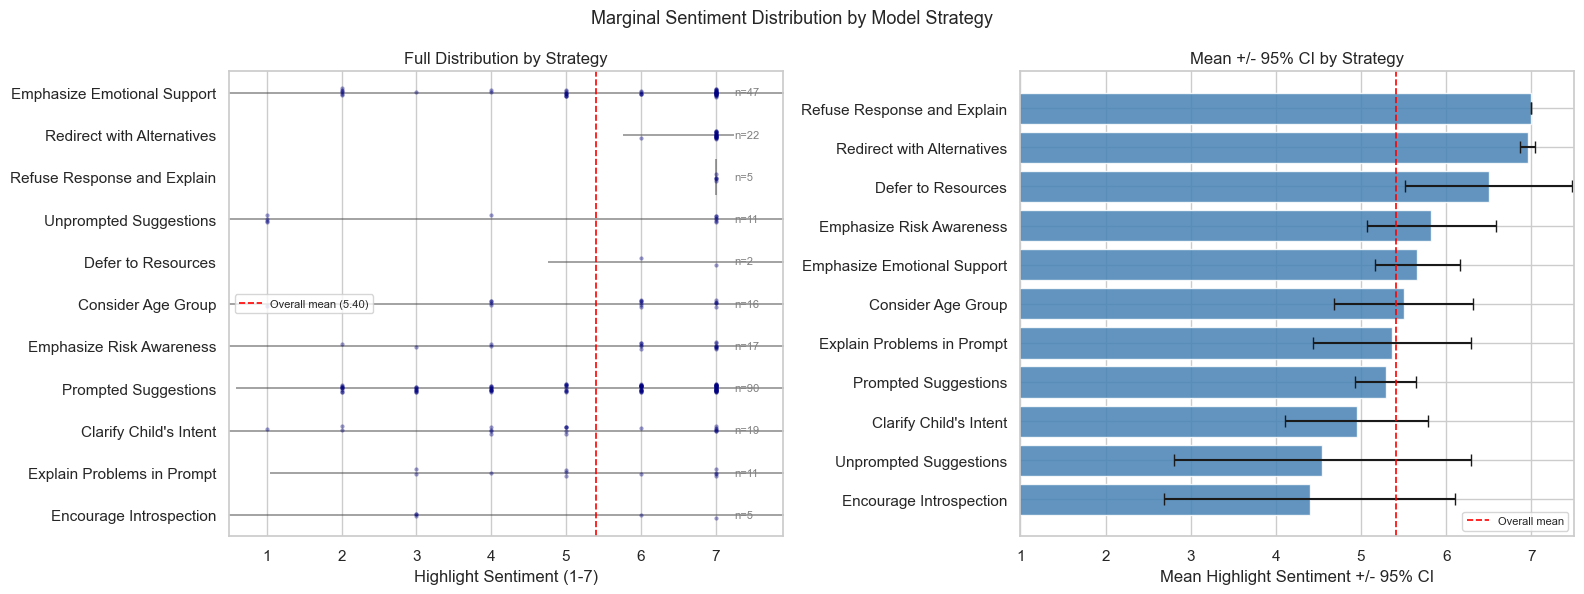


Strategy summary (ordered by median):


,mean,sem,count,median,pct_positive
model_strategy,,,,,
Emphasize Emotional Support,5.660,0.255,47,7.0,0.809
Redirect with Alternatives,6.955,0.045,22,7.0,1.000
Refuse Response and Explain,7.000,0.000,5,7.0,1.000
Unprompted Suggestions,4.545,0.888,11,7.0,0.545
Defer to Resources,6.500,0.500,2,6.5,1.000
Consider Age Group,5.500,0.418,16,6.0,0.688
Emphasize Risk Awareness,5.824,0.386,17,6.0,0.765
Prompted Suggestions,5.289,0.182,90,6.0,0.678
Clarify Child's Intent,4.947,0.429,19,5.0,0.632


In [15]:
strat_stats = (
    df_strat.groupby('model_strategy')['highlight_sentiment']
    .agg(['mean', 'sem', 'count', 'median'])
    .sort_values('median', ascending=False)
)
strat_order = strat_stats.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(strat_order) * 0.55)))

# Panel A — Violin + strip (full distribution shape)
ax = axes[0]
sns.violinplot(
    data=df_strat, x='highlight_sentiment', y='model_strategy',
    order=strat_order, inner=None, color='steelblue', alpha=0.5, ax=ax
)
sns.stripplot(
    data=df_strat, x='highlight_sentiment', y='model_strategy',
    order=strat_order, color='navy', alpha=0.4, size=3, jitter=True, ax=ax
)
ax.axvline(OVERALL_MEAN, color='red', linestyle='--', lw=1.2,
           label=f'Overall mean ({OVERALL_MEAN:.2f})')
for i, code in enumerate(strat_order):
    n = int(strat_stats.loc[code, 'count'])
    ax.text(7.25, i, f'n={n}', va='center', fontsize=8, color='gray')
ax.set_xlim(0.5, 7.9)
ax.set_xlabel('Highlight Sentiment (1-7)')
ax.set_ylabel('')
ax.set_title('Full Distribution by Strategy')
ax.legend(fontsize=8)

# Panel B — Mean +/- 95% CI (reusing R5 1b pattern)
ax = axes[1]
strat_ci = strat_stats.sort_values('mean')
ax.barh(strat_ci.index, strat_ci['mean'], xerr=1.96 * strat_ci['sem'],
        color='steelblue', capsize=4, alpha=0.85)
ax.axvline(OVERALL_MEAN, color='red', linestyle='--', lw=1.2, label='Overall mean')
ax.set_xlim(1, 7.5)
ax.set_xlabel('Mean Highlight Sentiment +/- 95% CI')
ax.set_ylabel('')
ax.set_title('Mean +/- 95% CI by Strategy')
ax.legend(fontsize=8)

fig.suptitle('Marginal Sentiment Distribution by Model Strategy', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'marginal_sentiment_by_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

strat_pct = (
    df_strat.groupby('model_strategy')
    .apply(lambda g: (g['highlight_sentiment'] >= 5).mean())
    .rename('pct_positive')
)
print('\nStrategy summary (ordered by median):')
display(strat_stats.join(strat_pct).round(3))

## Part 0c — Motivation: Marginal Distributions

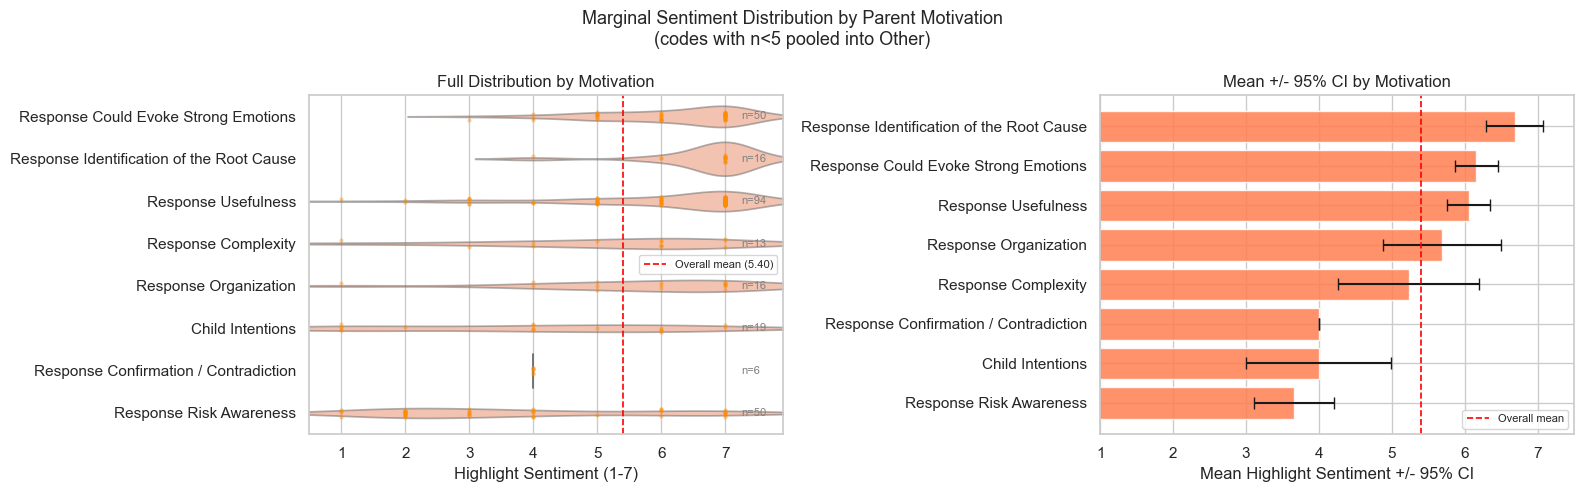


Motivation summary (ordered by median):


,mean,sem,count,median,pct_positive
motivation_pooled,,,,,
Response Could Evoke Strong Emotions,6.160,0.149,50,7.0,0.920
Response Identification of the Root Cause,6.688,0.198,16,7.0,0.938
Response Usefulness,6.053,0.148,94,7.0,0.872
Response Complexity,5.231,0.496,13,6.0,0.692
Response Organization,5.688,0.416,16,6.0,0.812
Child Intentions,4.000,0.507,19,4.0,0.421
Response Confirmation / Contradiction,4.000,0.000,6,4.0,0.000
Response Risk Awareness,3.660,0.282,50,3.0,0.280



Sentiment range per motivation code (confirms sentiment-neutrality):


,min,max,mean
motivation_pooled,,,
Child Intentions,1,7,4.00
Response Complexity,1,7,5.23
Response Confirmation / Contradiction,4,4,4.00
Response Could Evoke Strong Emotions,3,7,6.16
Response Identification of the Root Cause,4,7,6.69
Response Organization,1,7,5.69
Response Risk Awareness,1,7,3.66
Response Usefulness,1,7,6.05


In [16]:
motiv_stats = (
    df_motiv.groupby('motivation_pooled')['highlight_sentiment']
    .agg(['mean', 'sem', 'count', 'median'])
    .sort_values('median', ascending=False)
)
motiv_order = motiv_stats.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(motiv_order) * 0.55)))

# Panel A — Violin + strip
ax = axes[0]
sns.violinplot(
    data=df_motiv, x='highlight_sentiment', y='motivation_pooled',
    order=motiv_order, inner=None, color='coral', alpha=0.5, ax=ax
)
sns.stripplot(
    data=df_motiv, x='highlight_sentiment', y='motivation_pooled',
    order=motiv_order, color='darkorange', alpha=0.4, size=3, jitter=True, ax=ax
)
ax.axvline(OVERALL_MEAN, color='red', linestyle='--', lw=1.2,
           label=f'Overall mean ({OVERALL_MEAN:.2f})')
for i, code in enumerate(motiv_order):
    n = int(motiv_stats.loc[code, 'count'])
    ax.text(7.25, i, f'n={n}', va='center', fontsize=8, color='gray')
ax.set_xlim(0.5, 7.9)
ax.set_xlabel('Highlight Sentiment (1-7)')
ax.set_ylabel('')
ax.set_title('Full Distribution by Motivation')
ax.legend(fontsize=8)

# Panel B — Mean +/- 95% CI (reusing R5 2b pattern)
ax = axes[1]
motiv_ci = motiv_stats.sort_values('mean')
ax.barh(motiv_ci.index, motiv_ci['mean'], xerr=1.96 * motiv_ci['sem'],
        color='coral', capsize=4, alpha=0.85)
ax.axvline(OVERALL_MEAN, color='red', linestyle='--', lw=1.2, label='Overall mean')
ax.set_xlim(1, 7.5)
ax.set_xlabel('Mean Highlight Sentiment +/- 95% CI')
ax.set_ylabel('')
ax.set_title('Mean +/- 95% CI by Motivation')
ax.legend(fontsize=8)

fig.suptitle(
    'Marginal Sentiment Distribution by Parent Motivation\n'
    '(codes with n<5 pooled into Other)',
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'marginal_sentiment_by_motivation.png', dpi=150, bbox_inches='tight')
plt.show()

motiv_pct = (
    df_motiv.groupby('motivation_pooled')
    .apply(lambda g: (g['highlight_sentiment'] >= 5).mean())
    .rename('pct_positive')
)
print('\nMotivation summary (ordered by median):')
display(motiv_stats.join(motiv_pct).round(3))

print('\nSentiment range per motivation code (confirms sentiment-neutrality):')
display(
    df_motiv.groupby('motivation_pooled')['highlight_sentiment']
    .agg(['min', 'max', 'mean']).round(2)
)

In [17]:
# Save summary tables
strat_pct = (
    df_strat.groupby('model_strategy')
    .apply(lambda g: (g['highlight_sentiment'] >= 5).mean())
    .rename('pct_positive')
)
strat_stats.join(strat_pct).round(3).to_csv(OUTPUT_DIR / 'marginal_strategy_summary.csv')
print('Saved: marginal_strategy_summary.csv')

motiv_pct = (
    df_motiv.groupby('motivation_pooled')
    .apply(lambda g: (g['highlight_sentiment'] >= 5).mean())
    .rename('pct_positive')
)
motiv_stats.join(motiv_pct).round(3).to_csv(OUTPUT_DIR / 'marginal_motivation_summary.csv')
print('Saved: marginal_motivation_summary.csv')

Saved: marginal_strategy_summary.csv
Saved: marginal_motivation_summary.csv
